# Characterization of the standard deviation of the energy with respect to the laplacian method: can we train with a minimal approx?

**Objective**: with AD as the source of truth, how many terms in the hutchinson trace approximator do we need to have a good enough approx so that the training is well done? how does the std evolve? Can we train with minimal laplace approx (k=1) and then evaluate the model to get a good result?

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import optax
import flax.linen as nn
import matplotlib.pyplot as plt
from flax import struct
from scipy.linalg import eigh

from qvarnet import train
from qvarnet.config.training_setup import TrainingConfig, SamplingConfig
from qvarnet.config.coord_mode import LabCoords
from qvarnet.probability import build_prob_fn
from qvarnet.samplers import sample_and_process
from qvarnet import NoBoundary, PeriodicBoundary, BoundaryHamiltonian
from qvarnet.models import LogWavefunction, DeepSet, MLP
from qvarnet.hamiltonian import HarmonicOscillatorHamiltonian
from qvarnet.hamiltonian.continuous import NN_OscillatorHamiltonian
from qvarnet.boundaries import NoBoundary
from time import time

In [2]:
N_P     = 15          # bosons (unit filling: N = N_SITES)
N_DIM   = 1          # spatial dimensions per particle (1D)
N_CHAINS = 1000
N_EPOCHS = 5000

model = LogWavefunction(
    n_particles=N_P,
    n_dim=N_DIM,
    transform=NoBoundary(),
    # network=MLP(hidden=[128]),
    network=DeepSet(phi_hidden=[16], F_hidden=[8])
)


def train_wrt_laplacian(laplacian: str, k_terms_hutchinson: int, hutchinson_distribution):
     
    # hamiltonian = HarmonicOscillatorHamiltonian(omega=1.0, laplacian_method=laplacian, hutchinson_n_terms=k_terms_hutchinson)
    hamiltonian = NN_OscillatorHamiltonian(laplacian_method=laplacian, hutchinson_n_terms=k_terms_hutchinson, hutchinson_distribution=hutchinson_distribution)
    
    result = train(
        shape=(N_CHAINS, N_P),
        model=model,
        optimizer=optax.adam(3e-3),
        hamiltonian=hamiltonian,
        training_config=TrainingConfig(
            n_epochs=N_EPOCHS,
            is_update_step_size=True,
            target_acceptance=0.5,
            checkpoint_path="./checkpoints/bose-hubbard",
        ),
        sampler_params=SamplingConfig(
            step_size=0.3,
            chain_length=100,
            thermalization_steps=90,
            thinning_factor=5,
        ),
        coord_mode=LabCoords(),
    )
    return result

class Run:
    def __init__(self, is_ad: bool = True, k_terms_hutchinson: int = 1, hutchinson_sampler: str = "rademacher"):
        self.laplacian_method = "forward_ad" if is_ad else "hutchinson"
        self.k_terms_hutchinson = k_terms_hutchinson
        self.hutchinson_sampler = hutchinson_sampler
        self.run_result = None
        self.time_taken = None
    
    def run(self):
        start_time = time()
        result =  train_wrt_laplacian(
            laplacian=self.laplacian_method,
            k_terms_hutchinson=self.k_terms_hutchinson,
            hutchinson_distribution=self.hutchinson_sampler
        )
        end_time = time()
        self.run_result = result
        self.time_taken = end_time - start_time

In [3]:
# test a single run

run = Run(is_ad=True)
# run.run()
# print(f"Time taken for AD run: {run.time_taken:.2f} seconds")

In [4]:
samplers = ["rademacher", "gaussian"]
k_terms_list = np.linspace(1, 30, 10, dtype=int)
runs = [Run(is_ad=True)] + [Run(is_ad=False, k_terms_hutchinson=k, hutchinson_sampler=sampler) for sampler in samplers for k in k_terms_list]

print(len(runs))

21


In [5]:
for run in runs:
    run.run()
    print(f"Completed run with laplacian_method={run.laplacian_method}, k_terms_hutchinson={run.k_terms_hutchinson}, hutchinson_sampler={run.hutchinson_sampler} in {run.time_taken:.2f} seconds")

100%|██████████| 5000/5000 [00:27<00:00, 179.60it/s, E=13.0637, sigma_E=1.4547]  


Completed run with laplacian_method=forward_ad, k_terms_hutchinson=1, hutchinson_sampler=rademacher in 31.06 seconds


100%|██████████| 5000/5000 [00:18<00:00, 273.38it/s, E=13.0276, sigma_E=1.5165]  


Completed run with laplacian_method=hutchinson, k_terms_hutchinson=1, hutchinson_sampler=rademacher in 19.30 seconds


100%|██████████| 5000/5000 [00:20<00:00, 241.87it/s, E=13.0453, sigma_E=1.3349]  


...

Completed run with laplacian_method=hutchinson, k_terms_hutchinson=23, hutchinson_sampler=gaussian in 30.87 seconds


100%|██████████| 5000/5000 [00:28<00:00, 175.92it/s, E=11.5576, sigma_E=1.3948]  


Completed run with laplacian_method=hutchinson, k_terms_hutchinson=26, hutchinson_sampler=gaussian in 29.48 seconds


100%|██████████| 5000/5000 [00:29<00:00, 169.38it/s, E=11.7249, sigma_E=1.3497]  


Completed run with laplacian_method=hutchinson, k_terms_hutchinson=30, hutchinson_sampler=gaussian in 30.57 seconds


In [6]:
class ResultsParser:
    def __init__(self, runs):
        self.runs = runs
        self.run_results = {f"{run.laplacian_method}, {run.k_terms_hutchinson} ({run.hutchinson_sampler})": run.run_result for run in runs}
        
    def _get_parameter_history(self, is_ad, k_terms_hutchinson, hutchinson_sampler, parameter_name):
        method_name = f"{'forward_ad' if is_ad else 'hutchinson'}, {k_terms_hutchinson} ({hutchinson_sampler})"
        return [getattr(s, parameter_name) for s in self.run_results[method_name].history]
    
    def get_energy_history(self, is_ad, k_terms_hutchinson, hutchinson_sampler, window_size = 1):
        return self._smooth_history(self._get_parameter_history(is_ad, k_terms_hutchinson, hutchinson_sampler, "energy"), window_size)
    
    def get_energy_std_history(self, is_ad, k_terms_hutchinson, hutchinson_sampler, window_size = 1):
        return self._smooth_history(self._get_parameter_history(is_ad, k_terms_hutchinson, hutchinson_sampler, "std"), window_size)
    
    def get_acceptance_history(self, is_ad, k_terms_hutchinson, hutchinson_sampler, window_size = 1):
        return self._smooth_history(self._get_parameter_history(is_ad, k_terms_hutchinson, hutchinson_sampler, "acceptance_rate"), window_size)
    
    def get_step_size_history(self, is_ad, k_terms_hutchinson, hutchinson_sampler, window_size = 1):
        return self._smooth_history(self._get_parameter_history(is_ad, k_terms_hutchinson, hutchinson_sampler, "step_size"), window_size)
    
    def _smooth_history(self, history, window_size=10):
        return np.convolve(history, np.ones(window_size)/window_size)
    

In [7]:
print(runs)

[<__main__.Run object at 0x7a2cc58c8cd0>, <__main__.Run object at 0x7a2cc58c8e10>, <__main__.Run object at 0x7a2d542b9480>, <__main__.Run object at 0x7a2cc58a5350>, <__main__.Run object at 0x7a2cc5908050>, <__main__.Run object at 0x7a2cc5871370>, <__main__.Run object at 0x7a2cc5871480>, <__main__.Run object at 0x7a2cc5856250>, <__main__.Run object at 0x7a2cc5856550>, <__main__.Run object at 0x7a2cc586d220>, <__main__.Run object at 0x7a2cc586d6d0>, <__main__.Run object at 0x7a2cc5d94670>, <__main__.Run object at 0x7a2cc58dcbb0>, <__main__.Run object at 0x7a2cc58aeea0>, <__main__.Run object at 0x7a2d544e5c10>, <__main__.Run object at 0x7a2cc5894a10>, <__main__.Run object at 0x7a2cc5dcd650>, <__main__.Run object at 0x7a2cc5dcd7b0>, <__main__.Run object at 0x7a2cc58e5310>, <__main__.Run object at 0x7a2cc58e71b0>, <__main__.Run object at 0x7a2cc5dee210>]


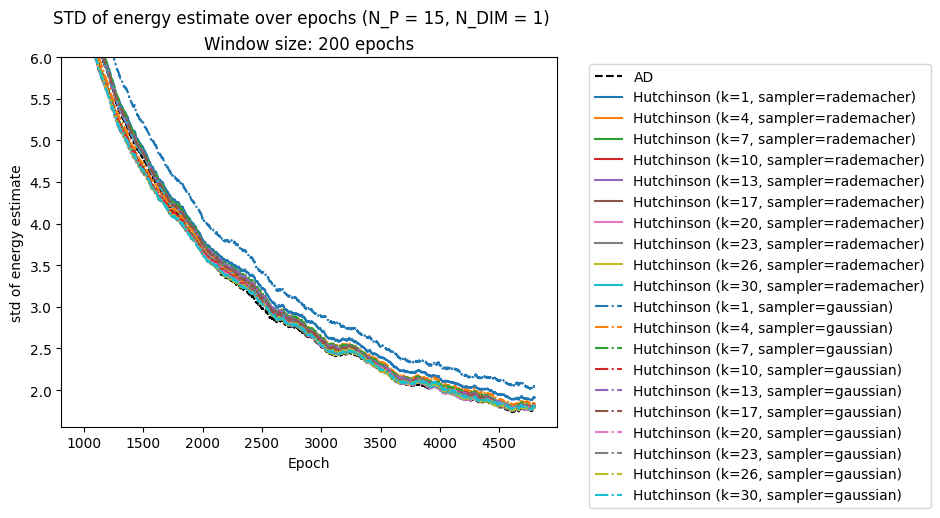

In [26]:
results_parser = ResultsParser(runs)

window = 200

INIT_PLOT_EPOCH = 1000
FIN_PLOT_EPOCH = N_EPOCHS-window




plt.plot(range(INIT_PLOT_EPOCH, FIN_PLOT_EPOCH),results_parser.get_energy_std_history(True, 1, "rademacher", window_size=window)[INIT_PLOT_EPOCH:FIN_PLOT_EPOCH], label="AD", color="black", ls="--" )

for sampler in samplers:
    if sampler == "gaussian":
        style = "-."
    else:
        style = "-"
    for k in k_terms_list:
        plt.plot(range(INIT_PLOT_EPOCH, FIN_PLOT_EPOCH),results_parser.get_energy_std_history(False, k, sampler, window_size=window)[INIT_PLOT_EPOCH:FIN_PLOT_EPOCH], label=f"Hutchinson (k={k}, sampler={sampler})", ls=style)
        
plt.xlabel("Epoch")
plt.ylim(min(results_parser.get_energy_std_history(True, 1, "rademacher", window_size=window)[INIT_PLOT_EPOCH:FIN_PLOT_EPOCH])*0.9,
        6)
        #  max(results_parser.get_energy_std_history(True, 1, "rademacher", window_size=window)[INIT_PLOT_EPOCH:FIN_PLOT_EPOCH])*1.1)
plt.ylabel("std of energy estimate")
plt.title(f"Window size: {window} epochs")
plt.suptitle(f"STD of energy estimate over epochs (N_P = {N_P}, N_DIM = {N_DIM})")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

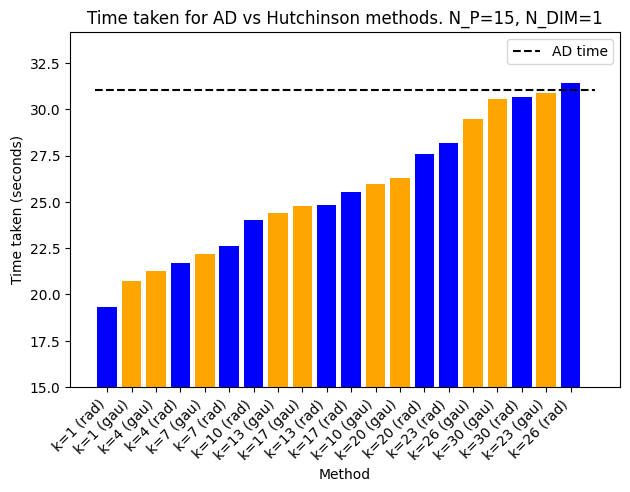

In [30]:
labels = [f"k={run.k_terms_hutchinson} ({run.hutchinson_sampler[:3]})"
            for run in runs if run.laplacian_method != "forward_ad"]

colour = ["blue" if run.hutchinson_sampler == "rademacher" else "orange" for run in runs if run.laplacian_method != "forward_ad"]

values = [run.time_taken for run in runs if run.laplacian_method != "forward_ad"]

labels, values, colour = zip(*sorted(
      zip(labels, values, colour),
      key=lambda x: x[1]  # sort by time
  ))


plt.bar(labels,values,color=colour)

plt.hlines([run.time_taken for run in runs if run.laplacian_method == "forward_ad"], xmin=-0.5, xmax=len(runs)-1, colors="black", linestyles="--", label="AD time")
plt.xlabel("Method")
plt.ylabel("Time taken (seconds)")

plt.legend()
plt.ylim(15, [run.time_taken for run in runs if run.laplacian_method == "forward_ad"][0]* 1.1)
plt.xticks(ticks=range(len(labels)), labels=labels, rotation=45, ha="right")
plt.tight_layout()  # prevents labels from being clipped
plt.title(f"Time taken for AD vs Hutchinson methods. N_P={N_P}, N_DIM={N_DIM}")
plt.show()

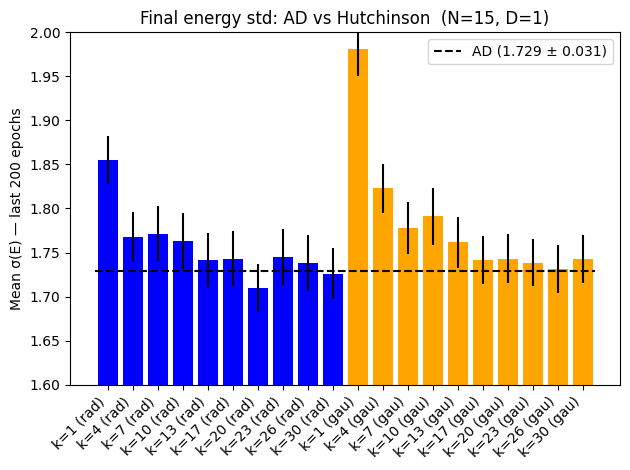

In [33]:
# plot final std of energy estimate as bars
FINAL_WINDOW = 200  # average over last N epochs

def final_std(run):
    history = [s.std for s in run.run_result.history]
    return np.mean(history[-FINAL_WINDOW:]), np.std(history[-FINAL_WINDOW:])/ np.sqrt(FINAL_WINDOW)  # return mean and standard error of the mean

labels   = [f"k={run.k_terms_hutchinson} ({run.hutchinson_sampler[:3]})"
            for run in runs if run.laplacian_method != "forward_ad"]
stds     = [final_std(run) for run in runs if run.laplacian_method != "forward_ad"]
ad_std_final = final_std(next(run for run in runs if run.laplacian_method == "forward_ad"))
colour = ["blue" if run.hutchinson_sampler == "rademacher" else "orange" for run in runs if run.laplacian_method != "forward_ad"]

plt.bar(range(len(labels)), [s[0] for s in stds], yerr=[s[1] for s in stds], color=colour)
plt.hlines(ad_std_final[0], xmin=-0.5, xmax=len(labels)-0.5,
           colors="black", linestyles="--", label=f"AD ({ad_std_final[0]:.3f} ± {ad_std_final[1]:.3f})")
plt.xticks(ticks=range(len(labels)), labels=labels, rotation=45, ha="right")
plt.ylabel("Mean σ(E) — last 200 epochs")
plt.title(f"Final energy std: AD vs Hutchinson  (N={N_P}, D={N_DIM})")
plt.ylim(1.6, 2)
plt.legend()
plt.tight_layout()
plt.show()